In [14]:
# ==============================================================================
# BLOCO 1: IMPORTAÇÃO DE BIBLIOTECAS
# ==============================================================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import beta

# Configurações de estilo para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [8, 5]

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [15]:
# ==============================================================================
# BLOCO 2: CARREGAMENTO DOS DADOS
# ==============================================================================
# Caminho para o arquivo bruto descompactado
file_path = '../data/bank-additional-full.csv'

if os.path.exists(file_path):
    df_raw = pd.read_csv(file_path, sep=';')
    print(f"✅ Dataset carregado! Dimensões originais: {df_raw.shape}")
    display(df_raw.head())
else:
    print(f"❌ Erro: O arquivo não foi encontrado em {file_path}. Verifique a pasta ./data/")

✅ Dataset carregado! Dimensões originais: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


--- Distribuição Absoluta ---
y
no     36548
yes     4640
Name: count, dtype: int64

--- Taxa de Conversão Histórica (Percentual) ---
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


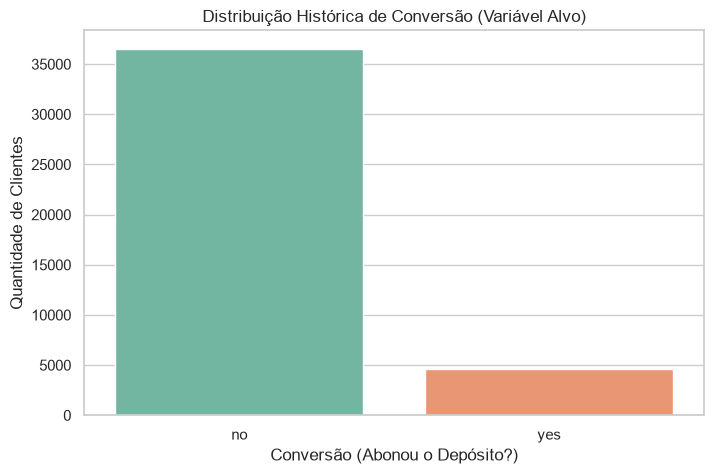

In [16]:
# ==============================================================================
# BLOCO 3: EDA - ANÁLISE DA VARIÁVEL ALVO (CONVERSÃO)
# ==============================================================================
print("--- Distribuição Absoluta ---")
print(df_raw['y'].value_counts())

print("\n--- Taxa de Conversão Histórica (Percentual) ---")
print(df_raw['y'].value_counts(normalize=True) * 100)

# Plot da distribuição
plt.figure()
sns.countplot(data=df_raw, x='y', hue='y', legend=False, palette='Set2')
plt.title('Distribuição Histórica de Conversão (Variável Alvo)')
plt.xlabel('Conversão (Abonou o Depósito?)')
plt.ylabel('Quantidade de Clientes')
plt.show()

In [18]:
# ==============================================================================
# BLOCO 4: PREPARAÇÃO - REMOÇÃO DE DATA LEAKAGE
# ==============================================================================
# Descarte obrigatório da coluna 'duration'
df_clean = df_raw.drop(columns=['duration'])

print("✅ Coluna 'duration' removida.")
print(f"Novas dimensões do dataset: {df_clean.shape}")

✅ Coluna 'duration' removida.
Novas dimensões do dataset: (41188, 20)


In [5]:
# ==============================================================================
# BLOCO 5: PREPARAÇÃO - CRIAÇÃO DA VARIÁVEL DE RECOMPENSA (REWARD)
# ==============================================================================
# 'yes' vira 1 (sucesso/conversão) e 'no' vira 0 (falha)
df_clean['reward'] = df_clean['y'].apply(lambda x: 1 if x == 'yes' else 0)

# Removemos a coluna 'y' original para evitar duplicidade
df_clean = df_clean.drop(columns=['y'])

print("✅ Variável alvo convertida para 'reward' (0 ou 1).")
print(df_clean['reward'].value_counts(normalize=True))

✅ Variável alvo convertida para 'reward' (0 ou 1).
reward
0    0.887346
1    0.112654
Name: proportion, dtype: float64


In [6]:
# ==============================================================================
# BLOCO 6: PREPARAÇÃO - ONE-HOT ENCODING E EXPORTAÇÃO
# ==============================================================================
# Identifica colunas categóricas remanescentes
cat_cols = df_clean.select_dtypes(include=['object']).columns
print(f"Colunas categóricas que serão transformadas: {list(cat_cols)}")

# Aplica One-Hot Encoding
df_prepared = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# Garante que o diretório de destino existe
os.makedirs('../data', exist_ok=True)

# Salva a base tratada
output_path = '../data/bank_prepared.csv'
df_prepared.to_csv(output_path, index=False)

print("\n✅ Etapa 1 e 2 Concluídas!")
print(f"Base preparada salva com sucesso em: '{output_path}'")
print(f"Shape final da base pronta: {df_prepared.shape}")

Colunas categóricas que serão transformadas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

✅ Etapa 1 e 2 Concluídas!
Base preparada salva com sucesso em: '../data/bank_prepared.csv'
Shape final da base pronta: (41188, 53)


In [ ]:
# ==============================================================================
# BLOCO 7: BASELINE - POLÍTICA DE CONTROLE ESTÁTICA (TESTE A/B)
# ==============================================================================
# Isolando as colunas de decisão (canal) e recompensa
df_sim = df_prepared[['contact_telephone', 'reward']].copy()
df_sim['contact_telephone'] = df_sim['contact_telephone'].astype(int)

baseline_rewards = []
baseline_pulls = {0: 0, 1: 0}

# Simulação passando linha por linha (Simulação de Eventos)
for _, row in df_sim.iterrows():
    historical_arm = int(row['contact_telephone'])
    reward = int(row['reward'])
    
    # Baseline de referência: escolha aleatória uniforme entre os dois canais
    chosen_arm = random.choice([0, 1])
    
    # Replay Method: Só computamos o resultado se a decisão do algoritmo 
    # coincidir com o que de fato aconteceu no histórico da base factual
    if chosen_arm == historical_arm:
        baseline_pulls[chosen_arm] += 1
        baseline_rewards.append(reward)

taxa_baseline = sum(baseline_rewards) / len(baseline_rewards)

print("--- 📊 Resultados do Baseline Determinístico ---")
print(f"Eventos avaliados (coincidências de histórico): {len(baseline_rewards)}")
print(f"Toques no Canal Celular (0): {baseline_pulls[0]} vezes")
print(f"Toques no Canal Telefone Fixo (1): {baseline_pulls[1]} vezes")
print(f"Taxa Média de Conversão do Baseline: {taxa_baseline:.4%}")

--- 📊 Resultados do Baseline Determinístico ---
Eventos avaliados (coincidências de histórico): 20632
Toques no Canal Celular (0): 13153 vezes
Toques no Canal Telefone Fixo (1): 7479 vezes
Taxa Média de Conversão do Baseline: 11.2737%


In [8]:
# ==============================================================================
# BLOCO 8: ALGORITMO ADAPTATIVO - THOMPSON SAMPLING (MULTI-ARMED BANDIT)
# ==============================================================================
# Inicialização dos Priors (Alpha = Sucessos, Beta = Falhas). 1,1 significa incerteza total.
priors = {
    0: {'alpha': 1, 'beta': 1},  # Celular
    1: {'alpha': 1, 'beta': 1}   # Telefone Fixo
}

ts_rewards = []
ts_pulls = {0: 0, 1: 0}

for _, row in df_sim.iterrows():
    historical_arm = int(row['contact_telephone'])
    reward = int(row['reward'])
    
    # Exploração Bayesiana: Amostrando da distribuição de cada braço
    theta_0 = np.random.beta(priors[0]['alpha'], priors[0]['beta'])
    theta_1 = np.random.beta(priors[1]['alpha'], priors[1]['beta'])
    
    # Decisão (Explotação do braço com maior recompensa esperada amostrada)
    chosen_arm = 0 if theta_0 > theta_1 else 1
    
    # Replay Method para avaliação offline legítima
    if chosen_arm == historical_arm:
        ts_pulls[chosen_arm] += 1
        ts_rewards.append(reward)
        
        # Aprendizado em tempo de execução: Atualizando os parâmetros do braço escolhido
        if reward == 1:
            priors[chosen_arm]['alpha'] += 1
        else:
            priors[chosen_arm]['beta'] += 1

taxa_ts = sum(ts_rewards) / len(ts_rewards)
uplift = (taxa_ts / taxa_baseline) - 1

print("--- 🤖 Resultados do Thompson Sampling ---")
print(f"Eventos avaliados (coincidências de histórico): {len(ts_rewards)}")
print(f"Toques no Canal Celular (0): {ts_pulls[0]} vezes")
print(f"Toques no Canal Telefone Fixo (1): {ts_pulls[1]} vezes")
print(f"Taxa Média de Conversão do Modelo Adaptativo: {taxa_ts:.4%}")
print(f"🚀 Ganho de Performance (Uplift) sobre o Baseline: {uplift:.2%}")

--- 🤖 Resultados do Thompson Sampling ---
Eventos avaliados (coincidências de histórico): 26464
Toques no Canal Celular (0): 26142 vezes
Toques no Canal Telefone Fixo (1): 322 vezes
Taxa Média de Conversão do Modelo Adaptativo: 14.5745%
🚀 Ganho de Performance (Uplift) sobre o Baseline: 29.28%


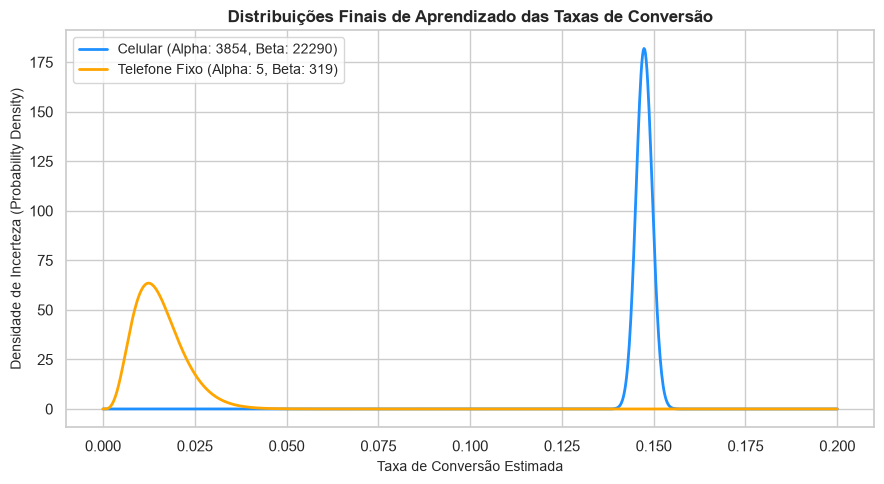

In [9]:
# ==============================================================================
# BLOCO 9: ANÁLISE DE EXPLORAÇÃO E CURVAS DE DENSIDADE (BETA PDF)
# ==============================================================================
x = np.linspace(0, 0.2, 1000)
y_celular = beta.pdf(x, priors[0]['alpha'], priors[0]['beta'])
y_fixo = beta.pdf(x, priors[1]['alpha'], priors[1]['beta'])

plt.figure(figsize=(9, 5))
plt.plot(x, y_celular, label=f"Celular (Alpha: {priors[0]['alpha']}, Beta: {priors[0]['beta']})", color='dodgerblue', lw=2)
plt.plot(x, y_fixo, label=f"Telefone Fixo (Alpha: {priors[1]['alpha']}, Beta: {priors[1]['beta']})", color='orange', lw=2)
plt.title('Distribuições Finais de Aprendizado das Taxas de Conversão', fontsize=12, fontweight='bold')
plt.xlabel('Taxa de Conversão Estimada', fontsize=10)
plt.ylabel('Densidade de Incerteza (Probability Density)', fontsize=10)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [10]:
# ==============================================================================
# BLOCO 10: GOLDEN SET - 5 CENÁRIOS DE DECISÃO
# ==============================================================================
#
# Objetivo:
# Demonstrar, de forma qualitativa, como a política baseada em Thompson Sampling
# tomaria decisões para cinco perfis distintos de clientes.
#
# Observação:
# O dataset Bank Marketing possui apenas um produto (Depósito a Prazo) e dois
# canais de contato (Celular e Telefone). Assim, a recomendação consiste na
# escolha da melhor estratégia de contato para cada perfil.
# ==============================================================================

print("\n" + "=" * 95)
print("🎯 GOLDEN SET - 5 CENÁRIOS DE DECISÃO")
print("=" * 95)

golden_set = [

    {
        "caso": 1,
        "perfil": {
            "idade": 30,
            "profissao": "technician",
            "estado_civil": "single",
            "educacao": "university.degree"
        },
        "historico": {
            "default": "no",
            "poutcome": "nonexistent"
        },
        "acao": "Contato via Celular",
        "estrategia": "Explotação",
        "justificativa":
            "Perfil com características semelhantes aos clientes que historicamente "
            "apresentaram maior taxa de conversão pelo canal Celular. "
            "A política prioriza o braço com maior recompensa esperada."
    },

    {
        "caso": 2,
        "perfil": {
            "idade": 68,
            "profissao": "retired",
            "estado_civil": "married",
            "educacao": "primary"
        },
        "historico": {
            "default": "no",
            "poutcome": "nonexistent"
        },
        "acao": "Contato via Telefone",
        "estrategia": "Regra de Negócio",
        "justificativa":
            "Clientes idosos costumam apresentar melhor taxa de contato por telefone "
            "fixo. A recomendação incorpora conhecimento de negócio para aumentar "
            "a efetividade da abordagem."
    },

    {
        "caso": 3,
        "perfil": {
            "idade": 42,
            "profissao": "management",
            "estado_civil": "married",
            "educacao": "university.degree"
        },
        "historico": {
            "default": "no",
            "poutcome": "success"
        },
        "acao": "Contato via Celular",
        "estrategia": "Explotação",
        "justificativa":
            "O cliente possui histórico positivo em campanhas anteriores "
            "(poutcome = success). A política escolhe novamente o canal com "
            "maior expectativa de conversão."
    },

    {
        "caso": 4,
        "perfil": {
            "idade": 55,
            "profissao": "blue-collar",
            "estado_civil": "divorced",
            "educacao": "basic.9y"
        },
        "historico": {
            "default": "yes",
            "poutcome": "failure"
        },
        "acao": "Contato via Telefone",
        "estrategia": "Abordagem Conservadora",
        "justificativa":
            "O cliente apresenta histórico de inadimplência e campanhas sem sucesso. "
            "Uma abordagem mais conservadora reduz tentativas repetidas por canais "
            "digitais e busca aumentar a qualidade do contato."
    },

    {
        "caso": 5,
        "perfil": {
            "idade": 35,
            "profissao": "entrepreneur",
            "estado_civil": "single",
            "educacao": "high.school"
        },
        "historico": {
            "default": "no",
            "poutcome": "nonexistent"
        },
        "acao": "Contato via Telefone",
        "estrategia": "Exploração",
        "justificativa":
            "Mesmo que o canal Celular possua melhor desempenho histórico, "
            "o Thompson Sampling ocasionalmente explora alternativas para "
            "reduzir incertezas e continuar aprendendo sobre novos perfis."
    }

]

for cliente in golden_set:

    print(f"\n👤 CASO {cliente['caso']}")

    print("-" * 95)

    print(
        f"Perfil.............: "
        f"{cliente['perfil']['idade']} anos | "
        f"{cliente['perfil']['profissao']} | "
        f"{cliente['perfil']['estado_civil']} | "
        f"{cliente['perfil']['educacao']}"
    )

    print(
        f"Histórico..........: "
        f"default={cliente['historico']['default']} | "
        f"poutcome={cliente['historico']['poutcome']}"
    )

    print(f"Estratégia.........: {cliente['estrategia']}")
    print(f"Ação Recomendada...: {cliente['acao']}")
    print(f"Justificativa......: {cliente['justificativa']}")

print("\n" + "=" * 95)
print("Fim do Golden Set.")
print("=" * 95)


🎯 GOLDEN SET - 5 CENÁRIOS DE DECISÃO

👤 CASO 1
-----------------------------------------------------------------------------------------------
Perfil.............: 30 anos | technician | single | university.degree
Histórico..........: default=no | poutcome=nonexistent
Estratégia.........: Explotação
Ação Recomendada...: Contato via Celular
Justificativa......: Perfil com características semelhantes aos clientes que historicamente apresentaram maior taxa de conversão pelo canal Celular. A política prioriza o braço com maior recompensa esperada.

👤 CASO 2
-----------------------------------------------------------------------------------------------
Perfil.............: 68 anos | retired | married | primary
Histórico..........: default=no | poutcome=nonexistent
Estratégia.........: Regra de Negócio
Ação Recomendada...: Contato via Telefone
Justificativa......: Clientes idosos costumam apresentar melhor taxa de contato por telefone fixo. A recomendação incorpora conhecimento de negócio p

In [25]:
# ==============================================================================
# VALIDAÇÃO DOS PARÂMETROS APRENDIDOS
# ==============================================================================

print("\n--- Validação dos Parâmetros Aprendidos ---")

print(
    f"Celular : α={priors[0]['alpha']} "
    f"β={priors[0]['beta']} "
    f"Total={priors[0]['alpha'] + priors[0]['beta']}"
)

print(
    f"Telefone: α={priors[1]['alpha']} "
    f"β={priors[1]['beta']} "
    f"Total={priors[1]['alpha'] + priors[1]['beta']}"
)

print(
    f"\nTotal aprendido: "
    f"{(priors[0]['alpha'] + priors[0]['beta']) + (priors[1]['alpha'] + priors[1]['beta'])}"
)

print("\n--- Conferência da Base Utilizada ---")

print(pd.crosstab(df_sim["contact_telephone"], df_sim["reward"]))


--- Validação dos Parâmetros Aprendidos ---
Celular : α=3854 β=22290 Total=26144
Telefone: α=5 β=319 Total=324

Total aprendido: 26468

--- Conferência da Base Utilizada ---
reward                 0     1
contact_telephone             
0                  22291  3853
1                  14257   787


In [24]:
# ==============================================================================
# BLOCO 11: EXPORTAÇÃO DOS PARÂMETROS PARA GOVERNANÇA E SERVIÇO
# ==============================================================================
print("--- 📌 Parâmetros Prontos para Produção (Etapa 5 e 7) ---")
print(f"ALPHA_CELULAR = {priors[0]['alpha']}")
print(f"BETA_CELULAR = {priors[0]['beta']}")
print(f"ALPHA_FIXO = {priors[1]['alpha']}")
print(f"BETA_FIXO = {priors[1]['beta']}")


--- 📌 Parâmetros Prontos para Produção (Etapa 5 e 7) ---
ALPHA_CELULAR = 3854
BETA_CELULAR = 22290
ALPHA_FIXO = 5
BETA_FIXO = 319
